In [1]:
import spatialdata as sd
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from spatialdata import get_extent
from spatialdata import bounding_box_query
from spatialdata import match_element_to_table
import spatialdata_plot
import numpy as np
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
from datatree import DataTree
from scipy.stats import spearmanr
from scipy.spatial.distance import cosine
from sklearn.neighbors import KernelDensity
from easydecon.easydecon import *
from easydecon.config import *
from spatialdata_plot.pl.utils import set_zero_in_cmap_to_transparent
from matplotlib.colors import ListedColormap
from matplotlib.colors import ListedColormap, BoundaryNorm

from mpl_toolkits.axes_grid1.inset_locator import inset_axes



pd.set_option('display.max_rows', 10)

In [3]:
set_n_jobs(5)
set_batch_size(1000)

In [4]:
# load a compatible color map for the spatial data
new_cmap = set_zero_in_cmap_to_transparent(cmap="viridis")


In [5]:
bin_size=8
sample_id="kidney"

sdata=spatialdata_io.visium_hd("/projects/ec56/projects/visiumhd/kidney/binned_outputs/",fullres_image_file="/fp/projects01/ec56/projects/visiumhd/kidney/Visium_HD_Human_Kidney_FFPE_tissue_image.btf",
                               bin_size=bin_size,dataset_id=sample_id,load_all_images=True)
sdata

SpatialData object
├── Images
│     ├── 'kidney_cytassist_image': DataArray[cyx] (3, 3000, 3200)
│     ├── 'kidney_full_image': DataTree[cyx] (3, 43999, 32674), (3, 21999, 16337), (3, 10999, 8168), (3, 5499, 4084), (3, 2749, 2042)
│     ├── 'kidney_hires_image': DataArray[cyx] (3, 6000, 4456)
│     └── 'kidney_lowres_image': DataArray[cyx] (3, 600, 446)
├── Shapes
│     └── 'kidney_square_008um': GeoDataFrame shape: (666695, 1) (2D shapes)
└── Tables
      └── 'square_008um': AnnData (666695, 18132)
with coordinate systems:
    ▸ 'downscaled_hires', with elements:
        kidney_hires_image (Images), kidney_square_008um (Shapes)
    ▸ 'downscaled_lowres', with elements:
        kidney_lowres_image (Images), kidney_square_008um (Shapes)
    ▸ 'global', with elements:
        kidney_cytassist_image (Images), kidney_full_image (Images), kidney_square_008um (Shapes)

In [6]:
# to align the high resolution image with the spatial data, we need to run this part
data_extent=get_extent(sdata[f"{sample_id}_square_00{bin_size}um"])

queried_cytassist = bounding_box_query(
    sdata[f"{sample_id}_full_image"],
    min_coordinate=[data_extent["x"][0], data_extent["y"][0]],
    max_coordinate=[data_extent["x"][1], data_extent["y"][1]],
    axes=("x", "y"),
    target_coordinate_system="global",
)

sdata["queried_cytassist"]=queried_cytassist

In [7]:
for table in sdata.tables.values():
   table.var_names_make_unique()
   sc.pp.calculate_qc_metrics(table, inplace=True)
   sc.pp.filter_genes(table, min_cells=10)
   sc.pp.filter_cells(table, min_counts=10)
   sc.pp.normalize_total(table, inplace=True,target_sum=1e4)
   sc.pp.log1p(table)
   #sc.pp.scale(table)
   #sc.pp.pca(table)
   #sc.pp.neighbors(table)
   #sc.tl.umap(table)

#here we filter the spatial data to only include the cells that are in the table
sdata.shapes[f"{sample_id}_square_00{bin_size}um"]=sdata.shapes[f"{sample_id}_square_00{bin_size}um"][sdata.shapes[f"{sample_id}_square_00{bin_size}um"].index.isin(sdata.tables[f"square_00{bin_size}um"].obs["location_id"])]

mt_genes = sdata.tables[f"square_00{bin_size}um"].var_names.str.startswith('MT-')
mt_genes



sdata.tables[f"square_00{bin_size}um"] = sdata.tables[f"square_00{bin_size}um"][:,~mt_genes]
table=sdata.tables[f"square_00{bin_size}um"]


/fp/homes01/u01/ec-sinanuu/miniconda3/envs/easydecon_test1/lib/python3.11/site-packages/spatialdata/_core/_elements.py:96: UserWarning: Key `kidney_square_008um` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/fp/homes01/u01/ec-sinanuu/miniconda3/envs/easydecon_test1/lib/python3.11/site-packages/spatialdata/_core/_elements.py:116: UserWarning: Key `square_008um` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


In [8]:
adata=sc.read_h5ad('/projects/ec56/projects/visiumhd/pelka/adata3.h5ad')
adata

AnnData object with n_obs × n_vars = 371223 × 43282
    obs: 'X', 'Y', 'ClusterFull', 'ClusterMidway', 'ClusterTop', 'celltype'
    uns: 'celltype_colors', 'dendrogram_ClusterTop', 'dendrogram_celltype', 'pca', 'rank_genes_groups'
    obsm: 'X_pca'
    varm: 'PCs'

In [26]:
markers_df_top60lf=read_markers_dataframe(sdata,adata=adata,top_n_genes=60,sort_by_column='scores')

#markers_df_top60lf is the dataframe that contains the top 60 genes that are differentially expressed in the Pelka study.
markers_df_top60lf.index.value_counts()

Unique cell types detected in the dataframe:
['Epi', 'TNKILC', 'Plasma', 'Myeloid', 'B', 'Strom', 'Mast']
Categories (7, object): ['B', 'Epi', 'Mast', 'Myeloid', 'Plasma', 'Strom', 'TNKILC']


group
B          60
Epi        60
Mast       60
Myeloid    60
Plasma     60
Strom      60
TNKILC     60
Name: count, dtype: int64

In [27]:
df_cluster_sum_permutation=common_markers_gene_expression_and_filter(sdata,markers_df_top60lf,num_permutations=5000,aggregation_method="sum",alpha=0.001,subsample_size=50000,parametric=False)

Subsample 10000/50000 for B:   0%|          | 0/1000 [00:00<?, ?it/s]

Subsample 20000/50000 for B:   0%|          | 0/1000 [00:00<?, ?it/s]

Subsample 30000/50000 for B:   0%|          | 0/1000 [00:00<?, ?it/s]

Subsample 40000/50000 for B:   0%|          | 0/1000 [00:00<?, ?it/s]

Subsample 50000/50000 for B:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Subsample 20000/50000 for TNKILC:   0%|          | 0/1000 [00:00<?, ?it/s]

Subsample 30000/50000 for TNKILC:   0%|          | 0/1000 [00:00<?, ?it/s]

Subsample 40000/50000 for TNKILC:   0%|          | 0/1000 [00:00<?, ?it/s]

Subsample 50000/50000 for TNKILC:   0%|          | 0/1000 [00:00<?, ?it/s]

Adding results to table.obs of sdata object


In [28]:
(sdata.tables[f"square_00{bin_size}um"].obs["Plasma"] >0).sum()

594

DataFrame added to SpatialData object
Index(['B', 'Epi', 'Mast', 'Myeloid', 'Plasma', 'Strom', 'TNKILC'], dtype='object')
INFO     Using matplotlib                                                                                          
INFO     Using matplotlib                                                                                          
INFO     Using matplotlib                                                                                          
INFO     Using matplotlib                                                                                          
INFO     Using matplotlib                                                                                          
INFO     Using matplotlib                                                                                          
INFO     Using matplotlib                                                                                          
INFO     Using matplotlib                                         

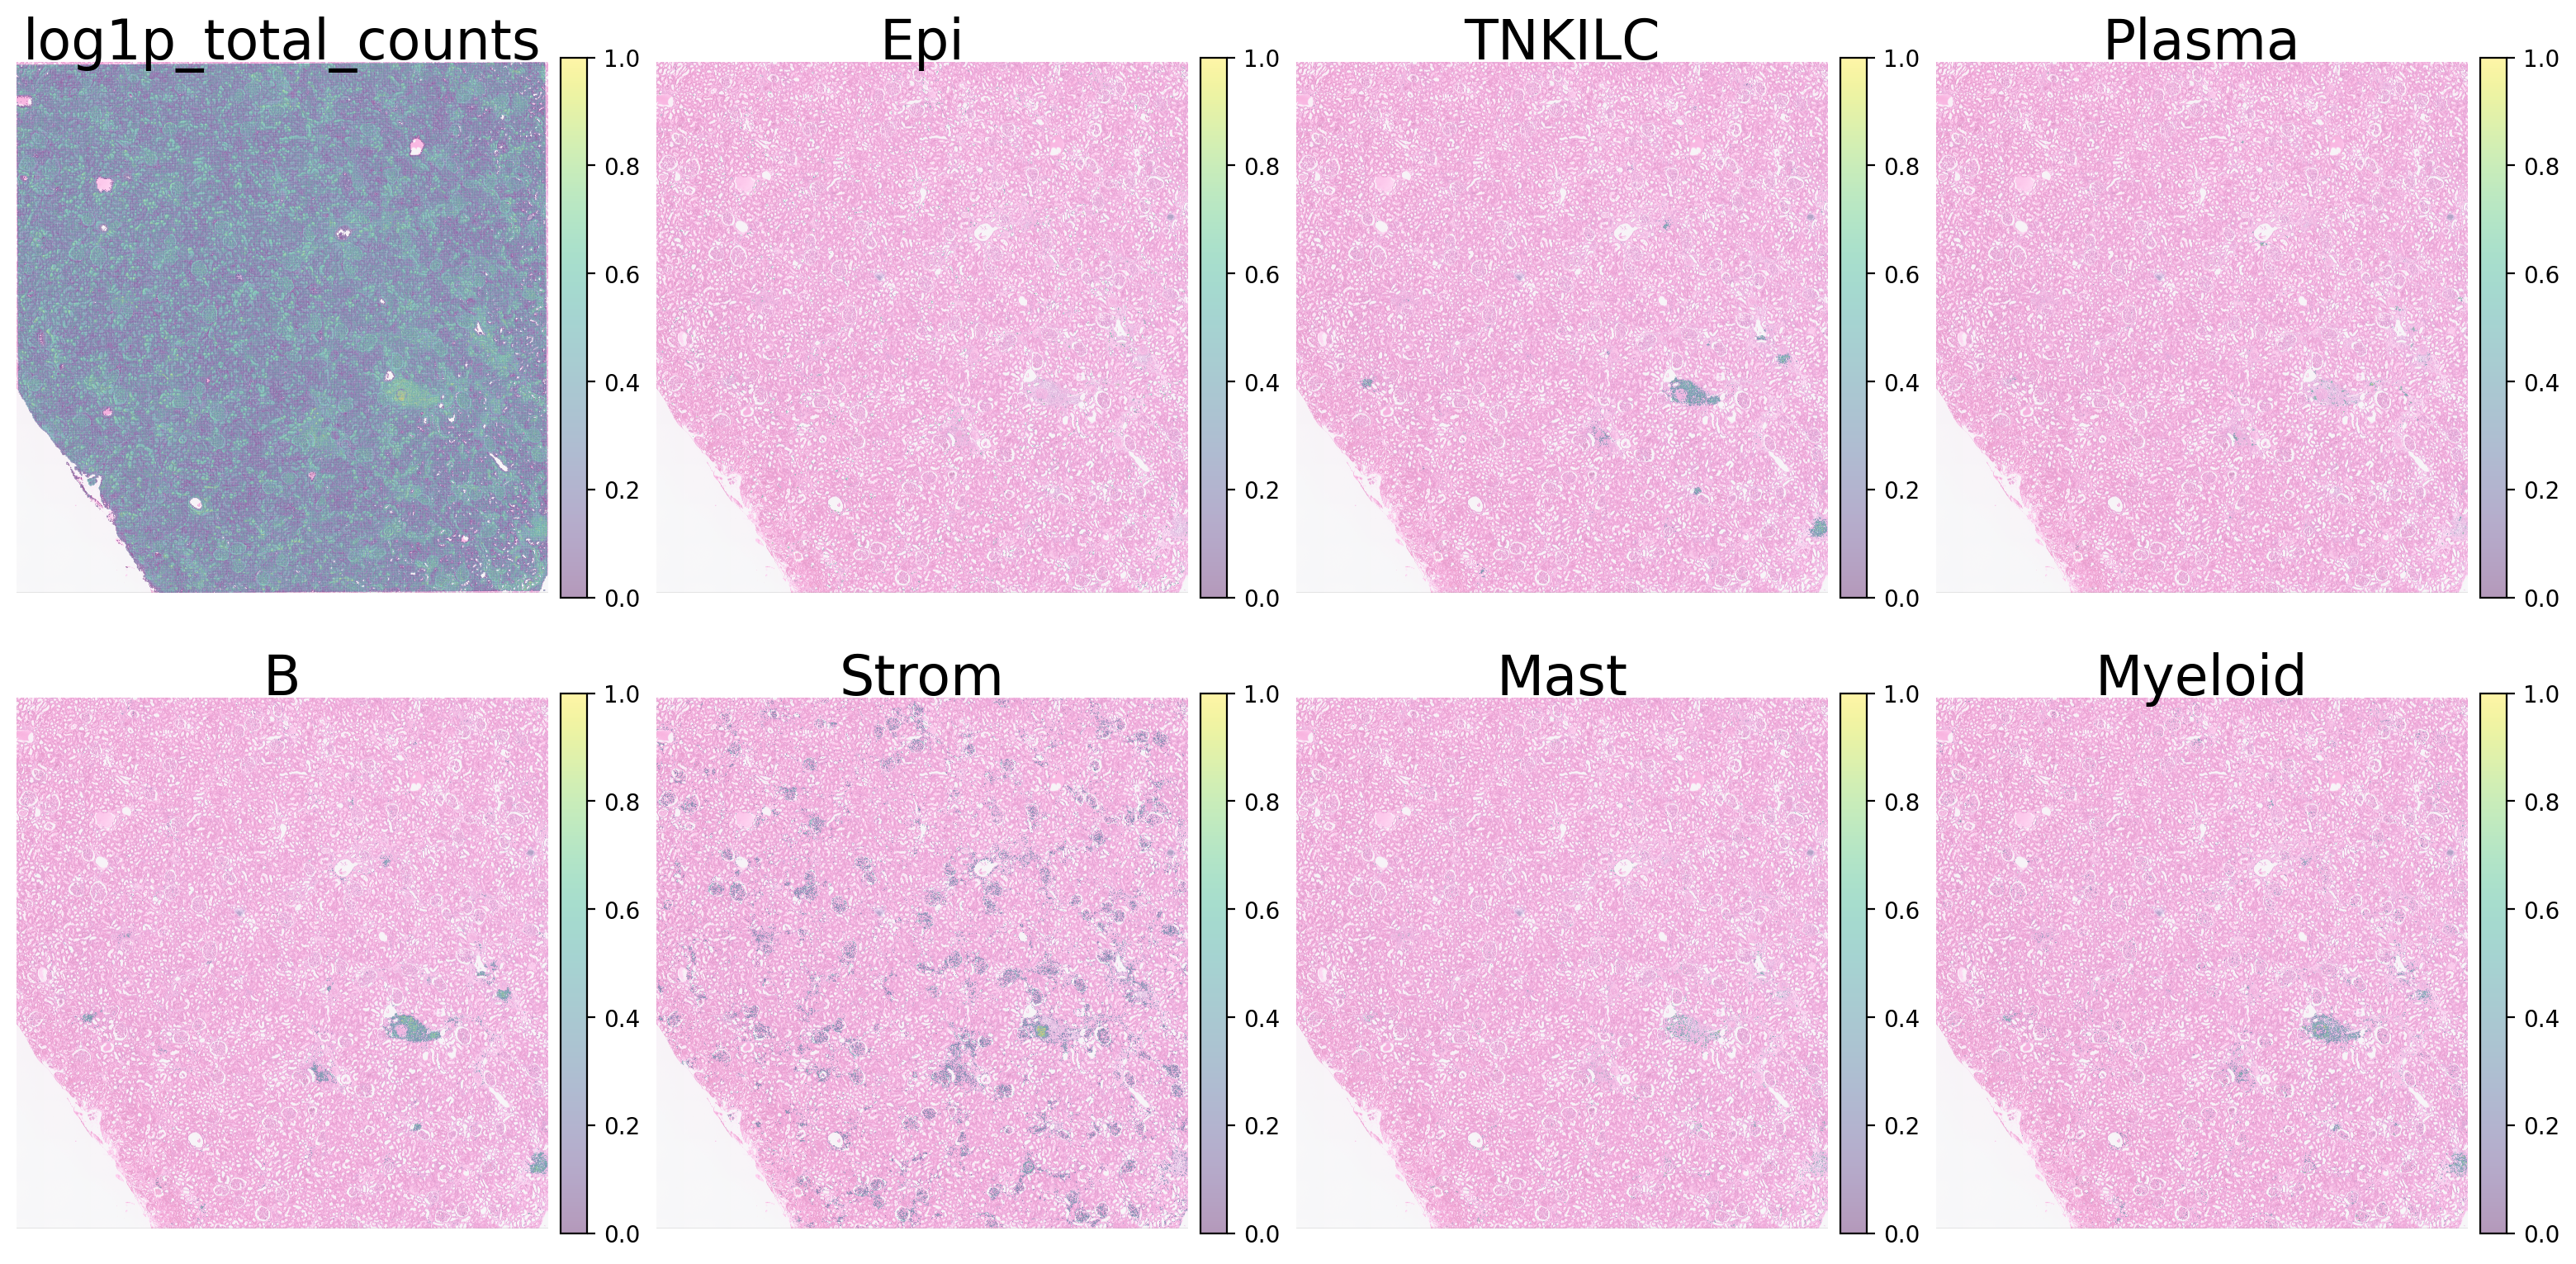

In [29]:
add_df_to_spatialdata(sdata,df_cluster_sum_permutation)
import matplotlib.pyplot as plt

cell_types = ['log1p_total_counts', 'Epi', 'TNKILC', 'Plasma', 'B', 'Strom', 'Mast', 'Myeloid']

# Create a figure with a GridSpec layout
fig = plt.figure(figsize=(20, 10))  # Adjust size as needed
gs = fig.add_gridspec(nrows=2, ncols=4, hspace=0, wspace=0)  # Adjust hspace and wspace

# Create subplots using the GridSpec
axs = gs.subplots(sharex=True, sharey=True)

for ax, cell_type in zip(axs.flat, cell_types):
    # Render the spatial plot and display it in the given Axes
    sdata.pl.render_images("queried_cytassist",alpha = 0.4).pl.render_shapes(
        f"{sample_id}_square_00{bin_size}um",
        color=cell_type,
        cmap=new_cmap,
        method="matplotlib",
        scale=0.8,
    ).pl.show(
        coordinate_systems="global",
        title=None,  # Title managed manually
        legend_fontsize=None,
        figsize=None,  # Size managed by the main figure
        dpi=200,
        return_ax=False,
        ax=ax,  # Pass the Axes object
        colorbar=False  # Add colorbars to each subplot
    )

    im = ax.images[0]
    cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02) 
    # Customize the Axes appearance
    ax.set_title(cell_type, fontsize=24, y=0.98)  # Add title for each subplot
    ax.axis('off')  # Remove ticks and borders
    


# Save the final figure
plt.savefig(f"main_groups_spatial_plots_with_colorbars_sum_fitting_{sample_id}.pdf", dpi=300, bbox_inches="tight")
plt.show()
